# Quick Backtest (Notebook)

- 이 노트북은 `VAA_전략` 프로젝트를 Jupyter에서 빠르게 실행하기 위한 용도입니다.
- `src.cli`를 거치지 않고 `src.backtest.engine.run_backtest()`를 직접 호출합니다.

> 주의: 첫 실행 시 yfinance 다운로드로 시간이 걸릴 수 있습니다.

In [89]:
from __future__ import annotations



import os

import sys

from pathlib import Path



import pandas as pd





def _detect_project_root() -> Path:

    """현재 실행 위치가 어디든 `VAA_전략` 프로젝트 루트를 찾아냅니다."""

    cwd = Path.cwd().resolve()



    candidates: list[Path] = []



    # 1) 현재 위치/상위에서 직접 찾기

    candidates.append(cwd)

    candidates.extend(list(cwd.parents))



    # 2) 흔한 워크스페이스 배치(Desktop/pj2/... 등) 대비

    candidates.extend(

        [

            cwd / "project2" / "VAA_전략",

            cwd / "pj2" / "project2" / "VAA_전략",

            cwd.parent / "project2" / "VAA_전략",

            cwd.parent / "pj2" / "project2" / "VAA_전략",

        ]

    )



    seen: set[Path] = set()

    for root in candidates:

        root = root.resolve()

        if root in seen:

            continue

        seen.add(root)



        cfg = root / "configs" / "config.yaml"

        src = root / "src"

        if cfg.exists() and src.exists():

            return root



    raise FileNotFoundError(

        "프로젝트 루트를 찾지 못했습니다. "

        "(기대: <project_root>/configs/config.yaml, <project_root>/src)\n"

        f"현재 작업 디렉토리: {cwd}"

    )





# -------------------------------

# 프로젝트 루트 설정

# -------------------------------

PROJECT_ROOT = _detect_project_root()

os.chdir(PROJECT_ROOT)



# `python -m src.cli` 대신 노트북에서 import가 되도록 sys.path에 루트를 추가합니다.

if str(PROJECT_ROOT) not in sys.path:

    sys.path.insert(0, str(PROJECT_ROOT))



print("PROJECT_ROOT =", PROJECT_ROOT)


PROJECT_ROOT = C:\Users\jeeho\Desktop\pj2\project2\VAA_전략


In [90]:
# -------------------------------

# 백테스트 파라미터

# -------------------------------

CONFIG_PATH = PROJECT_ROOT / "configs" / "config.yaml"



# 아래 두 값만 바꾸면 테스트 기간이 변경됩니다.

START = "2018-01-01"

END = "2025-12-31"



# 기간별로 결과를 분리 저장 (폴더명이 겹치지 않게)

_run_tag = f"nb_{START.replace('-', '')}_{END.replace('-', '')}"

OUTDIR = PROJECT_ROOT / "outputs" / _run_tag



PLOT = True



print("CONFIG_PATH =", CONFIG_PATH)

print("OUTDIR      =", OUTDIR)

print("START       =", START)

print("END         =", END)


CONFIG_PATH = C:\Users\jeeho\Desktop\pj2\project2\VAA_전략\configs\config.yaml
OUTDIR      = C:\Users\jeeho\Desktop\pj2\project2\VAA_전략\outputs\nb_20180101_20251231
START       = 2018-01-01
END         = 2025-12-31


In [91]:
# -------------------------------
# 백테스트 실행
# -------------------------------
from src.config.loader import load_config
from src.backtest.engine import run_backtest

config = load_config(CONFIG_PATH)
artifacts = run_backtest(config=config, start=START, end=END, outdir=OUTDIR, plot=PLOT)

print('done')
artifacts.metrics

done


{'CAGR': 0.15873529110634643,
 'Vol': 0.2790061449353094,
 'Sharpe': 0.6687368591093548,
 'MDD': -0.5133961560561575}

In [92]:
# -------------------------------
# 저장된 결과 빠르게 확인
# -------------------------------
metrics_path = OUTDIR / 'metrics.json'
daily_path = OUTDIR / 'daily_returns.csv'
monthly_path = OUTDIR / 'monthly_returns.csv'

print('metrics.json:', metrics_path)
print('daily_returns.csv:', daily_path)
print('monthly_returns.csv:', monthly_path)

daily = pd.read_csv(daily_path, index_col=0, parse_dates=True)
monthly = pd.read_csv(monthly_path, index_col=0, parse_dates=True)

display(daily.head())
display(monthly.head())

metrics.json: C:\Users\jeeho\Desktop\pj2\project2\VAA_전략\outputs\nb_20180101_20251231\metrics.json
daily_returns.csv: C:\Users\jeeho\Desktop\pj2\project2\VAA_전략\outputs\nb_20180101_20251231\daily_returns.csv
monthly_returns.csv: C:\Users\jeeho\Desktop\pj2\project2\VAA_전략\outputs\nb_20180101_20251231\monthly_returns.csv


,portfolio_return,equity,cost
Date,,,
2018-01-02,0.0,1.0,0.0
2018-01-03,0.0,1.0,0.0
2018-01-04,0.0,1.0,0.0
2018-01-05,0.0,1.0,0.0
2018-01-08,0.0,1.0,0.0


,month_return,equity
Date,,
2018-01-31,0.0,1.0
2018-02-28,0.0,1.0
2018-03-29,0.0,1.0
2018-04-30,0.0,1.0
2018-05-31,0.0,1.0


In [ ]:
# -------------------------------
# 레짐(카나리아) + 헷지(Short-cover) 타임라인 로드 / 오버레이 헬퍼
# -------------------------------
import numpy as np
import pandas as pd

regime_path = OUTDIR / "regime_timeline.csv"
print("regime_timeline.csv:", regime_path)

regime_timeline = pd.read_csv(regime_path, index_col=0, parse_dates=True)

# 일간 레짐/헷지 시리즈 (전 플롯에서 공통 사용)
regime_daily = regime_timeline["regime"].astype(object).reindex(daily.index, method="ffill")
short_cover_state_daily = regime_timeline["short_cover_state"].astype(str).reindex(daily.index, method="ffill")
hedge_on_daily = short_cover_state_daily.eq("ON")

# 월말(마지막 거래일) 기준 레짐/헷지 시리즈 (월별 히트맵/자산군 비중용)
regime_month_end = regime_daily.reindex(monthly.index, method="ffill")
hedge_on_month_end = hedge_on_daily.reindex(monthly.index, method="ffill").fillna(False)

REGIME_COLORS = {
    "ATTACK": "#b7e4c7",   # 연녹
    "NEUTRAL": "#ffe8a1",  # 연노랑
    "DEFENSE": "#f8c0c8",  # 연분홍
}

def _iter_segments(s: pd.Series):
    """연속 구간(start, end, value)을 생성합니다 (end는 포함)."""
    s = s.dropna()
    if len(s) == 0:
        return
    idx = pd.DatetimeIndex(s.index)
    values = s.values
    start = idx[0]
    prev = values[0]
    for i in range(1, len(idx)):
        if values[i] != prev:
            yield start, idx[i - 1], prev
            start = idx[i]
            prev = values[i]
    yield start, idx[-1], prev

def _overlay_canary_regime(ax, regime_s: pd.Series, alpha: float = 0.18) -> None:
    """카나리아 레짐(ATTACK/NEUTRAL/DEFENSE)을 배경 음영으로 표시합니다."""
    if regime_s is None or len(regime_s) == 0:
        return
    rs = regime_s.dropna().astype(object)
    for start, end, r in _iter_segments(rs):
        c = REGIME_COLORS.get(str(r), None)
        if c is None:
            continue
        ax.axvspan(start, end, color=c, alpha=alpha, lw=0)

def _overlay_hedge_state(ax, hedge_on_s: pd.Series, color: str = "#1d4ed8", alpha: float = 0.35) -> None:
    """헷지(Short-cover ON) 구간을 상단 얇은 밴드로 표시합니다."""
    if hedge_on_s is None or len(hedge_on_s) == 0:
        return
    hs = hedge_on_s.dropna().astype(bool)
    for start, end, on in _iter_segments(hs):
        if bool(on):
            ax.axvspan(start, end, ymin=0.97, ymax=1.0, color=color, alpha=alpha, lw=0)

def _add_regime_legend(ax) -> None:
    import matplotlib.patches as mpatches
    handles, labels = ax.get_legend_handles_labels()
    extra = [
        mpatches.Patch(color=REGIME_COLORS["ATTACK"], alpha=0.35, label="Canary Regime: ATTACK"),
        mpatches.Patch(color=REGIME_COLORS["NEUTRAL"], alpha=0.35, label="Canary Regime: NEUTRAL"),
        mpatches.Patch(color=REGIME_COLORS["DEFENSE"], alpha=0.35, label="Canary Regime: DEFENSE"),
        mpatches.Patch(color="#1d4ed8", alpha=0.35, label="Hedge Regime: Short-cover ON"),
    ]
    handles = handles + extra
    labels = labels + [h.get_label() for h in extra]
    ax.legend(handles=handles, labels=labels, loc="upper left", ncol=2, frameon=True)

## 성과지표 / 그래프 / 월별 히트맵



> 아래 셀들은 `outputs/` 아래에 저장된 결과를 기반으로 빠르게 시각화합니다.


In [93]:
# -------------------------------
# 성과지표(표 형태로 보기)
# -------------------------------
import json

import pandas as pd

with open(metrics_path, "r", encoding="utf-8") as f:
    metrics = json.load(f)

metrics_df = (
    pd.DataFrame([metrics])
    .T
    .rename(columns={0: "value"})
)

# 보기 좋게 소수점 정리
def _fmt(v: object) -> object:
    if isinstance(v, (int, float)):
        return round(float(v), 4)
    return v

metrics_df["value"] = metrics_df["value"].map(_fmt)
display(metrics_df)

,value
CAGR,0.1587
Vol,0.2790
Sharpe,0.6687
MDD,-0.5134


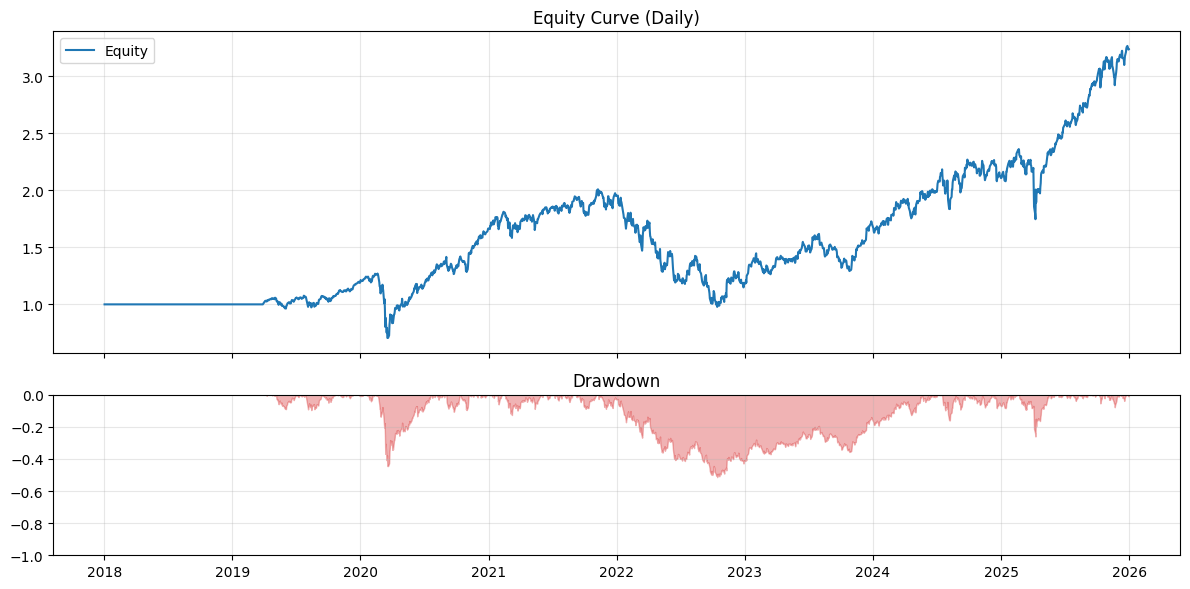

In [ ]:
# -------------------------------
# 그래프: 일간 Equity + Drawdown (+ 레짐/헷지 오버레이)
# -------------------------------
import numpy as np
import matplotlib.pyplot as plt

equity = daily["equity"].astype(float)
peak = equity.cummax()
drawdown = equity / peak - 1.0

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(equity.index, equity.values, label="Equity")
axes[0].set_title("Equity Curve (Daily)")
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(drawdown.index, drawdown.values, 0.0, color="tab:red", alpha=0.35)
axes[1].set_title("Drawdown")
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-1.0, 0.0)

# 레짐(카나리아) + 헷지(Short-cover ON) 오버레이
_overlay_canary_regime(axes[0], regime_daily)
_overlay_hedge_state(axes[0], hedge_on_daily)
_overlay_canary_regime(axes[1], regime_daily)
_overlay_hedge_state(axes[1], hedge_on_daily)
_add_regime_legend(axes[0])

fig.tight_layout()
plt.show()

## 벤치마크 비교 (SPY / 1-N)



- SPY Buy&Hold

- 공격군(ATTACK) 유니버스 1/N

- 방어군(DEFENSE) 유니버스 1/N

- 전체 유니버스(ATTACK+NEUTRAL+DEFENSE) 1/N



> 참고: 유니버스 정의는 `src.portfolio.policies.DEFAULT_UNIVERSE`를 그대로 사용합니다.


,CAGR,Vol,Sharpe,MDD
Strategy,0.158735,0.279006,0.668737,-0.513396
SPY,0.142619,0.194526,0.783110,-0.337173
EW_Attack,0.124699,0.206778,0.672294,-0.322372
EW_Defense,0.058959,0.083580,0.727312,-0.175342
EW_Total,0.101625,0.138467,0.768567,-0.240777


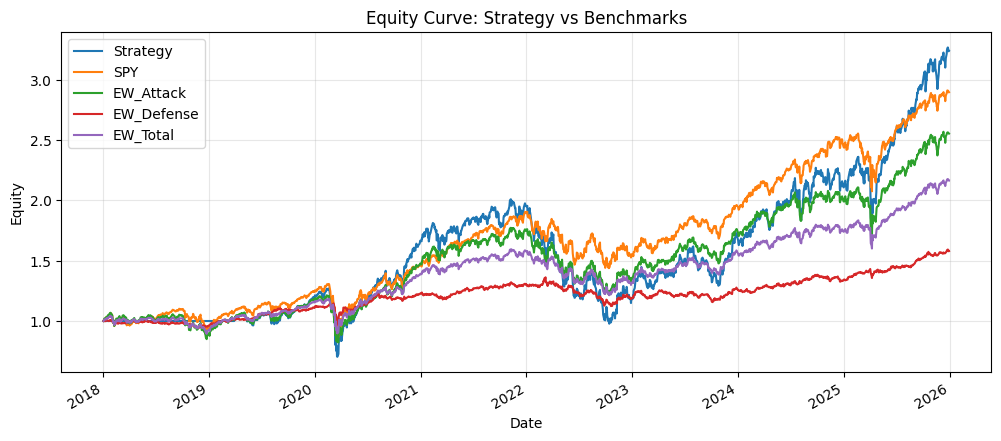

In [ ]:
# -------------------------------

# 벤치마크 포트폴리오 계산 (일간) + 레짐/헷지 오버레이

# -------------------------------

import numpy as np

import matplotlib.pyplot as plt



from src.data.fetch_yahoo import fetch_adj_close

from src.data.transforms import to_daily_returns

from src.portfolio.policies import DEFAULT_UNIVERSE

from src.backtest.metrics import compute_metrics, metrics_to_dict






def _equal_weight_returns(daily_returns: pd.DataFrame, tickers: list[str]) -> pd.Series:

    """주어진 티커들을 1/N로 보유했다고 가정한 일간 수익률을 계산합니다.

    구현상 결측(NaN)은 0% 수익률로 처리합니다.

    (엔진에서 `daily_returns_all.fillna(0.0)`로 처리하는 철학과 맞추기 위함)
    """

    cols = [t.upper() for t in tickers]

    sub = daily_returns[cols].copy()

    return sub.fillna(0.0).mean(axis=1)






strategy_ret = daily["portfolio_return"].astype(float).fillna(0.0)




attack_universe = [t.upper() for t in DEFAULT_UNIVERSE.attack]
defense_universe = [t.upper() for t in DEFAULT_UNIVERSE.defense]
neutral_universe = [t.upper() for t in DEFAULT_UNIVERSE.neutral]
total_universe = sorted(set(attack_universe + defense_universe + neutral_universe))



bench_tickers = sorted(set(["SPY"] + total_universe))
bench_prices = fetch_adj_close(
    tickers=bench_tickers,
    start=START,
    end=END,
    ticker_aliases=config.get("ticker_aliases", {}),
).adj_close



bench_prices = bench_prices.reindex(daily.index).ffill()
bench_rets = to_daily_returns(bench_prices).reindex(daily.index)



spy_ret = bench_rets["SPY"].fillna(0.0)
ew_attack_ret = _equal_weight_returns(bench_rets, attack_universe)
ew_defense_ret = _equal_weight_returns(bench_rets, defense_universe)
ew_total_ret = _equal_weight_returns(bench_rets, total_universe)



compare_rets = pd.DataFrame(
    {
        "Strategy": strategy_ret,
        "SPY": spy_ret,
        "EW_Attack": ew_attack_ret,
        "EW_Defense": ew_defense_ret,
        "EW_Total": ew_total_ret,
    },
    index=daily.index,
)



compare_equity = (1.0 + compare_rets).cumprod()



metrics_table = {
    name: metrics_to_dict(compute_metrics(compare_rets[name]))
    for name in compare_rets.columns
}
metrics_table_df = pd.DataFrame(metrics_table).T
display(metrics_table_df)



ax = compare_equity.plot(figsize=(12, 5), title="Equity Curve: Strategy vs Benchmarks")
ax.grid(True, alpha=0.3)
ax.set_ylabel("Equity")

# 레짐/헷지 오버레이
_overlay_canary_regime(ax, regime_daily.reindex(compare_equity.index, method="ffill"))
_overlay_hedge_state(ax, hedge_on_daily.reindex(compare_equity.index, method="ffill").fillna(False))
_add_regime_legend(ax)

plt.show()

## 월별 수익률 히트맵



- `monthly_returns.csv` 기준으로 Year × Month 히트맵을 그립니다.


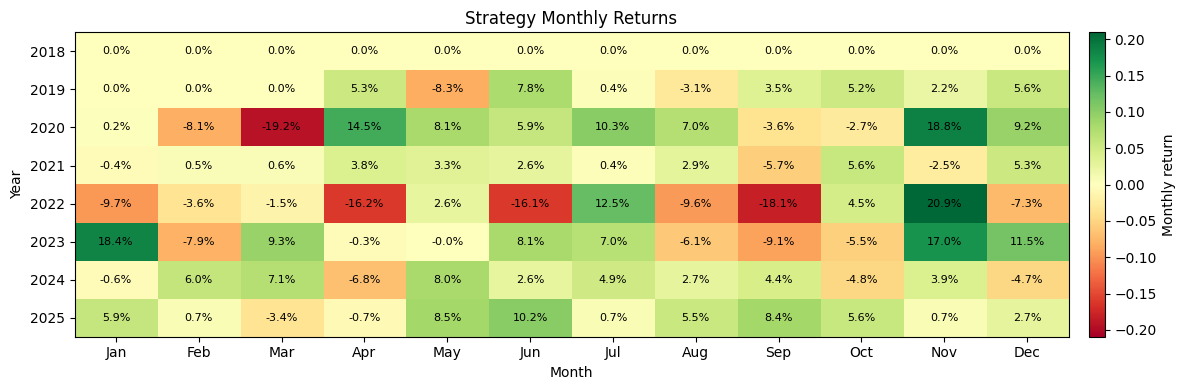

In [ ]:
import calendar
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

def _monthly_heatmap(
    monthly_returns: pd.Series,
    title: str = "Monthly Returns Heatmap",
    regime_series: pd.Series | None = None,
    hedge_on_series: pd.Series | None = None,
) -> None:
    """월별 수익률(단일 시리즈)을 Year x Month 히트맵으로 표시합니다.

    regime_series / hedge_on_series가 제공되면 동일한 격자(Year x Month)로
    상단에 레짐(카나리아)과 헷지(Short-cover ON) 히트맵을 추가합니다.
    """
    mr = monthly_returns.copy().dropna()
    if not isinstance(mr.index, pd.DatetimeIndex):
        mr.index = pd.to_datetime(mr.index)

    df = mr.to_frame("ret")
    df["year"] = df.index.year
    df["month"] = df.index.month

    if regime_series is not None:
        rs = regime_series.reindex(df.index, method="ffill").astype(object)
        df["regime"] = rs
        regime_code = rs.map({"DEFENSE": 0, "NEUTRAL": 1, "ATTACK": 2}).astype(float)
        df["regime_code"] = regime_code
    if hedge_on_series is not None:
        hs = hedge_on_series.reindex(df.index, method="ffill").fillna(False).astype(bool)
        df["hedge_on"] = hs
        df["hedge_code"] = hs.astype(int).astype(float)

    pivot_ret = df.pivot(index="year", columns="month", values="ret").sort_index()
    pivot_ret = pivot_ret.reindex(columns=list(range(1, 13)))

    # optional pivots aligned to ret grid
    pivot_regime = None
    if "regime_code" in df.columns:
        pivot_regime = df.pivot(index="year", columns="month", values="regime_code").sort_index()
        pivot_regime = pivot_regime.reindex(index=pivot_ret.index, columns=pivot_ret.columns)
    pivot_hedge = None
    if "hedge_code" in df.columns:
        pivot_hedge = df.pivot(index="year", columns="month", values="hedge_code").sort_index()
        pivot_hedge = pivot_hedge.reindex(index=pivot_ret.index, columns=pivot_ret.columns)

    n_extra = int(pivot_regime is not None) + int(pivot_hedge is not None)
    if n_extra > 0:
        fig_h = max(5, 0.55 * len(pivot_ret))
        fig = plt.figure(figsize=(12, fig_h))
        import matplotlib.gridspec as gridspec
        gs = gridspec.GridSpec(nrows=1 + n_extra, ncols=1, height_ratios=[0.35] * n_extra + [4.0], hspace=0.05)
        axes = []
        for i in range(n_extra + 1):
            axes.append(fig.add_subplot(gs[i, 0]))
        ax_ret = axes[-1]
        extra_axes = axes[:-1]
    else:
        fig, ax_ret = plt.subplots(figsize=(12, max(4, 0.45 * len(pivot_ret))))
        extra_axes = []

    # Draw regime/hedge strips (same Year x Month grid, tiny height)
    extra_i = 0
    if pivot_regime is not None:
        ax_r = extra_axes[extra_i]
        extra_i += 1
        cmap = mcolors.ListedColormap([REGIME_COLORS["DEFENSE"], REGIME_COLORS["NEUTRAL"], REGIME_COLORS["ATTACK"]])
        ax_r.imshow(pivot_regime.values, aspect="auto", cmap=cmap, vmin=0, vmax=2)
        ax_r.set_yticks(range(len(pivot_ret.index)))
        ax_r.set_yticklabels(pivot_ret.index.astype(str).tolist(), fontsize=8)
        ax_r.set_xticks([])
        ax_r.set_title("Canary Regime (monthly)")
        ax_r.set_ylabel("Year")
        ax_r.grid(False)
        for spine in ax_r.spines.values():
            spine.set_visible(False)
    if pivot_hedge is not None:
        ax_h = extra_axes[extra_i]
        extra_i += 1
        cmap = mcolors.ListedColormap(["#ffffff", "#1d4ed8"])
        ax_h.imshow(pivot_hedge.values, aspect="auto", cmap=cmap, vmin=0, vmax=1)
        ax_h.set_yticks(range(len(pivot_ret.index)))
        ax_h.set_yticklabels(pivot_ret.index.astype(str).tolist(), fontsize=8)
        ax_h.set_xticks([])
        ax_h.set_title("Hedge Regime (Short-cover ON)")
        ax_h.set_ylabel("Year")
        ax_h.grid(False)
        for spine in ax_h.spines.values():
            spine.set_visible(False)

    # Returns heatmap
    data = pivot_ret.values
    vmax = np.nanmax(np.abs(data)) if np.isfinite(data).any() else 0.0
    vmax = float(vmax) if vmax > 0 else 0.10
    im = ax_ret.imshow(data, aspect="auto", cmap="RdYlGn", vmin=-vmax, vmax=vmax)

    ax_ret.set_title(title)
    ax_ret.set_xlabel("Month")
    ax_ret.set_ylabel("Year")
    ax_ret.set_xticks(range(12))
    ax_ret.set_xticklabels([calendar.month_abbr[m] for m in range(1, 13)])
    ax_ret.set_yticks(range(len(pivot_ret.index)))
    ax_ret.set_yticklabels(pivot_ret.index.astype(str).tolist())

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if np.isfinite(val):
                ax_ret.text(j, i, f"{val*100:.1f}%", ha="center", va="center", fontsize=8)

    fig.colorbar(im, ax=ax_ret, fraction=0.03, pad=0.02, label="Monthly return")

    # Legend (optional)
    legend_items = []
    if pivot_regime is not None:
        legend_items += [
            mpatches.Patch(color=REGIME_COLORS["ATTACK"], alpha=0.35, label="ATTACK"),
            mpatches.Patch(color=REGIME_COLORS["NEUTRAL"], alpha=0.35, label="NEUTRAL"),
            mpatches.Patch(color=REGIME_COLORS["DEFENSE"], alpha=0.35, label="DEFENSE"),
        ]
    if pivot_hedge is not None:
        legend_items += [
            mpatches.Patch(color="#1d4ed8", alpha=0.35, label="Short-cover ON"),
        ]
    if len(legend_items) > 0:
        ax_ret.legend(handles=legend_items, loc="upper left", ncol=4, frameon=True)

    plt.tight_layout()
    plt.show()

# `monthly` DataFrame은 위에서 outputs에서 로드됨 (monthly_returns.csv)
if "portfolio_return" in monthly.columns:
    monthly_ret = monthly["portfolio_return"].astype(float)
else:
    monthly_ret = monthly.iloc[:, 0].astype(float)

_monthly_heatmap(
    monthly_ret,
    title="Strategy Monthly Returns (+ Canary Regime & Hedge Regime)",
    regime_series=regime_month_end,
    hedge_on_series=hedge_on_month_end,
)

## 월별 자산군(Asset Class) 비중



- `weights.csv`(분기 리밸런싱 로그)를 일간으로 전개(ffill)한 뒤, 월말(마지막 거래일) 기준으로 자산군별 비중을 합산해 시각화합니다.


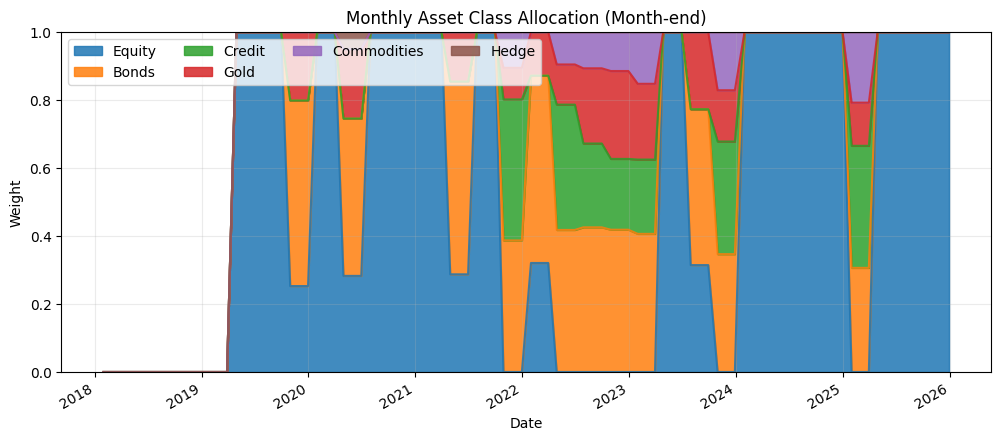

,avg_weight_last12m
Equity,0.750000
Bonds,0.076549
Credit,0.089748
Gold,0.031734
Commodities,0.051969
Hedge,0.000000


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _extract_weights_from_weights_log(weights_log: pd.DataFrame) -> pd.DataFrame:
    """weights.csv(리밸런싱 로그)에서 w_ 컬럼만 뽑아 weights DataFrame으로 변환합니다."""
    w_cols = [c for c in weights_log.columns if str(c).startswith("w_")]
    w = weights_log[w_cols].copy()
    w.columns = [str(c)[2:].upper() for c in w.columns]  # w_SPY -> SPY
    w = w.apply(pd.to_numeric, errors="coerce").fillna(0.0)

    # 혹시 합이 1이 아닌 행이 있다면 정규화
    s = w.sum(axis=1)
    w = w.div(s.replace(0.0, np.nan), axis=0).fillna(0.0)
    return w

def _asset_class_map(universe: "Universe", hedge_ticker: str) -> dict[str, str]:
    """티커 -> 자산군 라벨 매핑(간단 휴리스틱)."""
    attack = {t.upper() for t in universe.attack}
    neutral = {t.upper() for t in universe.neutral}
    defense = {t.upper() for t in universe.defense}

    equity = {"SPY", "QQQ", "IWM", "EWJ", "EEM", "VGK", "SOX"} & (attack | neutral | defense)
    bonds = {"TLT", "BND", "LQD"} & (attack | neutral | defense | {"BND"})
    credit = {"HYG"} & (attack | neutral | defense)
    gold = {"GLD"} & (attack | neutral | defense)
    commodities = {"DBC"} & (attack | neutral | defense)
    usd = {"UUP"} & (attack | neutral | defense)

    mapping: dict[str, str] = {}
    for t in sorted(attack | neutral | defense | {hedge_ticker.upper()}):
        tu = t.upper()
        if tu == hedge_ticker.upper():
            mapping[tu] = "Hedge"
        elif tu in usd:
            mapping[tu] = "USD"
        elif tu in gold:
            mapping[tu] = "Gold"
        elif tu in commodities:
            mapping[tu] = "Commodities"
        elif tu in credit:
            mapping[tu] = "Credit"
        elif tu in bonds:
            mapping[tu] = "Bonds"
        elif tu in equity:
            mapping[tu] = "Equity"
        else:
            mapping[tu] = "Other"
    return mapping

# -------------------------------
# 월별 자산군 비중 계산/시각화 (+ 레짐/헷지 오버레이)
# -------------------------------
weights_path = OUTDIR / "weights.csv"
weights_log = pd.read_csv(weights_path, index_col=0, parse_dates=True)

w_rb = _extract_weights_from_weights_log(weights_log)

# 일간으로 전개(분기 리밸런싱 가정) -> 월말(마지막 거래일)로 샘플
w_daily = w_rb.reindex(daily.index, method="ffill").fillna(0.0)
w_month_end = w_daily.reindex(monthly.index, method="ffill").fillna(0.0)

# 자산군별 합산
hedge_ticker = str(config.get("hedge", {}).get("ticker", "SH")).upper()
ticker_to_class = _asset_class_map(DEFAULT_UNIVERSE, hedge_ticker=hedge_ticker)
classes = sorted(set(ticker_to_class.values()))

w_class = pd.DataFrame(index=w_month_end.index, columns=classes, dtype=float)
w_class[:] = 0.0

for t in w_month_end.columns:
    cls = ticker_to_class.get(str(t).upper(), "Other")
    w_class[cls] = w_class[cls] + w_month_end[t].astype(float)

# 보기 좋게 컬럼 순서 고정
preferred = ["Equity", "Bonds", "Credit", "Gold", "Commodities", "USD", "Hedge", "Other"]
w_class = w_class[[c for c in preferred if c in w_class.columns]]

ax = w_class.plot.area(figsize=(12, 5), alpha=0.85, title="Monthly Asset Class Allocation (Month-end)")
ax.set_ylabel("Weight")
ax.set_ylim(0.0, 1.0)
ax.grid(True, alpha=0.25)
plt.legend(loc="upper left", ncol=4)

# 레짐/헷지 오버레이(월말 기준)
_overlay_canary_regime(ax, regime_month_end)
_overlay_hedge_state(ax, hedge_on_month_end)
_add_regime_legend(ax)

plt.show()

# 최근 12개월 평균 비중(표)
last12 = w_class.tail(12)
display(last12.mean().to_frame("avg_weight_last12m"))